# P4 with P3 Forecasted February NTU

本 notebook 保持原 `p4_OR.ipynb` 的 OR-risk 方法基本不变，只增加一个连接步骤：

```text
P3 TW-Qin Formula-GRU
        ↓
预测 2026 年 2 月出厂水 NTU
        ↓
将 2 月 NTU 替换为 P3 forecast
        ↓
继续运行原 P4 OR-risk pipeline
```

也就是说：

- P4 的五维风险指标不改；
- OR-risk 公式不改；
- 风险等级阈值和 NTU=1 硬约束不改；
- 只把 2026 年 2 月的 `NTU` 输入换成 P3 预测结果；
- 1 月和 3 月仍使用原始观测 `NTU`。

In [2]:
# =========================
# 0. Global configuration
# =========================

from pathlib import Path

POSSIBLE_DATA_PATHS = [
    Path(r"E:\桌面\亚太杯\2026-Asia-Pacific-cup\data\merged.xlsx"),
    Path(r"E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("merged.xlsx"),
    Path("../data/merged.xlsx"),
    Path("../../data/merged.xlsx"),
]

# Feature ablation variant. The final value is selected by validation loss.
FEATURE_VARIANT = "baseline"

OUTPUT_DIR = Path(f"outputs/problem4_with_p3_feb_forecast/p3_TW_Qin/{FEATURE_VARIANT}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_DATETIME_COL = None
MANUAL_DATE_COL = "DATE"
MANUAL_TIME_COL = "TIME"
ALLOW_DATE_ONLY = False

TARGET_OVERRIDE = None

# Match the P1 clipped experiment: cap modeled NTU values at 2.0.
CLIP_NTU_UPPER = 2.0
CLIP_NTU_INPUTS = True

QIN_MODE = "TW"
QIN_COL = "T/W FLOW"

DT_HOURS = 2.0
EPS = 1e-6

LOOKBACK = 12
HORIZON = 6
HORIZON_HOURS = [2, 4, 6, 8, 10, 12]
EXPECTED_FREQ_HOURS = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 1e-3

HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.10

SEED = 42

REQUESTED_DATES = ["2026-02-01", "2026-02-10", "2026-02-20"]
REQUESTED_TIMES = ["07:00", "09:00", "11:00", "13:00", "15:00", "17:00", "19:00"]

NATIVE_GRID_START_TIME = "07:00"
NATIVE_BASE_TOLERANCE_HOURS = 1.1

USE_GAP_AWARE_SEQUENCES = True
ALLOW_ROW_ORDER_FALLBACK = True


# Expanding-window blocked time-series evaluation.
RUN_BLOCKED_CV = True
BLOCKED_CV_FOLDS = 4
BLOCKED_CV_INITIAL_TRAIN_RATIO = 0.50
BLOCKED_CV_BLOCK_RATIO = 0.10

print("Qin mode:", QIN_MODE, "| Qin column:", QIN_COL)
print("Feature variant:", FEATURE_VARIANT)
print("NTU clipping upper bound:", CLIP_NTU_UPPER)
print("Output directory:", OUTPUT_DIR.resolve())

Qin mode: TW | Qin column: T/W FLOW
Feature variant: baseline
NTU clipping upper bound: 2.0
Output directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\p4\outputs\problem4_with_p3_feb_forecast\p3_TW_Qin\baseline


In [3]:
# =========================
# 1. Imports and seed
# =========================

import os
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
# =========================
# 2. Load data and robust datetime reconstruction
# =========================

def find_data_path(possible_paths):
    for p in possible_paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        "merged.xlsx not found. Please put it at one of: "
        + ", ".join(str(p) for p in possible_paths)
    )

def parse_excel_or_regular_date(s):
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        values = numeric.dropna()
        if len(values) > 0 and values.between(20000, 60000).mean() >= 0.70:
            return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")
    return pd.to_datetime(s, errors="coerce")

def parse_time_to_timedelta(s):
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        vals = numeric.dropna()
        if len(vals) > 0:
            min_v, max_v = vals.min(), vals.max()
            if min_v >= 0 and max_v <= 1:
                return pd.to_timedelta(numeric, unit="D")
            if min_v >= 0 and max_v <= 24:
                return pd.to_timedelta(numeric, unit="h")
            if min_v >= 0 and max_v <= 2359:
                as_int = numeric.round().astype("Int64")
                hours = (as_int // 100).astype("float")
                minutes = (as_int % 100).astype("float")
                valid = (hours >= 0) & (hours <= 23) & (minutes >= 0) & (minutes <= 59)
                out = pd.Series(pd.NaT, index=s.index, dtype="timedelta64[ns]")
                out.loc[valid] = (
                    pd.to_timedelta(hours.loc[valid], unit="h") +
                    pd.to_timedelta(minutes.loc[valid], unit="m")
                )
                if out.notna().mean() >= 0.70:
                    return out

    text = s.astype(str).str.strip()
    parsed = pd.to_datetime(text, errors="coerce")
    return (
        pd.to_timedelta(parsed.dt.hour, unit="h") +
        pd.to_timedelta(parsed.dt.minute, unit="m") +
        pd.to_timedelta(parsed.dt.second, unit="s")
    )

def build_datetime_column(df):
    cols = list(df.columns)
    upper_map = {c: str(c).upper().strip() for c in cols}

    if MANUAL_DATETIME_COL is not None:
        parsed = pd.to_datetime(df[MANUAL_DATETIME_COL], errors="coerce")
        if parsed.notna().mean() < 0.70:
            raise ValueError("Manual datetime column cannot be parsed.")
        return parsed, MANUAL_DATETIME_COL

    if MANUAL_DATE_COL is not None and MANUAL_TIME_COL is not None:
        date_part = parse_excel_or_regular_date(df[MANUAL_DATE_COL]).dt.normalize()
        time_delta = parse_time_to_timedelta(df[MANUAL_TIME_COL])
        combined = date_part + time_delta
        if combined.notna().mean() < 0.70:
            raise ValueError("Manual DATE + TIME cannot be parsed.")
        return combined, f"{MANUAL_DATE_COL} + {MANUAL_TIME_COL}"

    date_keywords = ["DATE", "日期", "DAY", "日"]
    time_keywords = ["TIME", "时间", "HOUR", "小时", "时刻"]

    date_cols = [c for c in cols if any(k in upper_map[c] for k in date_keywords)]
    time_cols = [c for c in cols if any(k in upper_map[c] for k in time_keywords)]

    candidates = []
    for d in date_cols:
        for t in time_cols:
            if d == t:
                continue
            date_part = parse_excel_or_regular_date(df[d]).dt.normalize()
            time_delta = parse_time_to_timedelta(df[t])
            combined = date_part + time_delta
            candidates.append((combined.notna().mean(), combined.dropna().dt.strftime("%H:%M").nunique(), d, t, combined))

    candidates = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)
    for valid_rate, unique_times, d, t, combined in candidates:
        if valid_rate >= 0.70 and unique_times > 1:
            return combined, f"{d} + {t}"

    for c in cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() >= 0.70:
            return parsed, c

    raise ValueError("Cannot detect datetime column.")

def validate_datetime_resolution(df):
    dt = pd.to_datetime(df["DATETIME"])
    print("Unique time-of-day count:", dt.dt.strftime("%H:%M").nunique())
    print("\\nMost common time differences:")
    display(dt.sort_values().diff().value_counts().head(5).to_frame("count"))

data_path = find_data_path(POSSIBLE_DATA_PATHS)
print("Reading:", data_path.resolve())

data = pd.read_excel(data_path)
data.columns = [str(c).strip() for c in data.columns]

dt, dt_source = build_datetime_column(data)
data["DATETIME"] = dt

data = (
    data.dropna(subset=["DATETIME"])
        .sort_values("DATETIME")
        .drop_duplicates(subset=["DATETIME"], keep="first")
        .reset_index(drop=True)
)

print("Datetime source:", dt_source)
print("Shape:", data.shape)
print("Time range:", data["DATETIME"].min(), "to", data["DATETIME"].max())
validate_datetime_resolution(data)

print("\\nColumns:")
print(data.columns.tolist())

Reading: E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
Datetime source: DATE + TIME
Shape: (5460, 19)
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00
Unique time-of-day count: 12
\nMost common time differences:


,count
DATETIME,
0 days 02:00:00,5459


\nColumns:
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW', 'DATETIME']


In [5]:
# =========================
# 3. Correct target and formula-term features
# =========================

def norm_col(c):
    return str(c).upper().strip().replace(" ", "").replace("_", "").replace("-", "").replace("/", "").replace(".", "")

def detect_p3_target(df, override=None):
    cols = list(df.columns)
    if override is not None:
        if override not in df.columns:
            raise KeyError(f"TARGET_OVERRIDE not found: {override}")
        return override
    preferred = [
        "C/W NTU", "CW NTU", "CLEAR WATER NTU", "TREATED WATER NTU",
        "OUTLET NTU", "FINAL NTU", "EFFLUENT NTU",
        "出厂水浊度", "清水浊度", "处理后水浊度", "清水/处理后水浊度",
    ]
    norm_to_col = {norm_col(c): c for c in cols}
    for p in preferred:
        if norm_col(p) in norm_to_col:
            return norm_to_col[norm_col(p)]
    for c in ["NTU", "NTU.1", "NTU_1", "NTU (第二处)", "NTU第二处"]:
        if c in cols:
            return c
    ntu_cols = [c for c in cols if ("NTU" in str(c).upper() or "浊" in str(c)) and c not in ["R/W NTU", "FILT. NTU"]]
    if ntu_cols:
        return ntu_cols[-1]
    raise ValueError("Cannot detect P3 target. Set TARGET_OVERRIDE manually.")

TARGET = detect_p3_target(data, TARGET_OVERRIDE)
if TARGET in ["FILT. NTU", "R/W NTU"]:
    raise ValueError(f"Wrong target detected: {TARGET}. P3 target must be outlet/treated-water NTU.")

REQUIRED_COLS = [TARGET, "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]
missing = [c for c in REQUIRED_COLS if c not in data.columns]
if missing:
    raise KeyError("Missing columns required for formula-term GRU: " + str(missing))

data_pre = data.copy()
for c in REQUIRED_COLS:
    data_pre[c] = pd.to_numeric(data_pre[c], errors="coerce")

data_pre["TARGET_OBSERVED"] = data_pre[TARGET].notna()

# Apply the same upper clipping used by the P1 clipped experiment.
# Missing values remain missing here and are handled causally below.
ntu_clip_cols = [TARGET]
if CLIP_NTU_INPUTS and "FILT. NTU" in data_pre.columns:
    ntu_clip_cols.append("FILT. NTU")

clip_records = []
for c in ntu_clip_cols:
    valid_before = data_pre[c].dropna()
    clip_records.append({
        "column": c,
        "valid_count": len(valid_before),
        "count_above_clip_before": int((valid_before > CLIP_NTU_UPPER).sum()),
        "max_before": valid_before.max() if len(valid_before) else np.nan,
        "clip_upper": CLIP_NTU_UPPER,
    })
    data_pre[c] = data_pre[c].clip(upper=CLIP_NTU_UPPER)

ntu_clip_report_df = pd.DataFrame(clip_records)
display(ntu_clip_report_df)
pre_train_end = int(len(data_pre) * TRAIN_RATIO)
train_prefix = data_pre.iloc[:pre_train_end]

for c in [c for c in REQUIRED_COLS if c != TARGET]:
    fill_value = train_prefix[c].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    data_pre[c] = data_pre[c].ffill().fillna(fill_value)

target_history_fill = train_prefix.loc[train_prefix[TARGET].notna(), TARGET].median()
if pd.isna(target_history_fill):
    raise ValueError("No observed target values are available in the training block.")
data_pre[TARGET] = data_pre[TARGET].ffill().fillna(target_history_fill)

well_level = data_pre["C/W WELL LEVEL"].astype(float)
well_level_fallback = train_prefix["C/W WELL LEVEL"].abs().replace(0, np.nan).median()
if pd.isna(well_level_fallback):
    well_level_fallback = 1.0
well_level_safe = well_level.abs().where(well_level.abs() > EPS).ffill().fillna(well_level_fallback) + EPS

current_ntu = data_pre[TARGET].astype(float)
filt_ntu = data_pre["FILT. NTU"].astype(float)
rw_flow = data_pre["R/W FLOW"].astype(float)
tw_flow = data_pre["T/W FLOW"].astype(float)
qin = rw_flow if QIN_MODE == "RW" else tw_flow
qout = tw_flow

data_pre["current_NTU"] = current_ntu
data_pre["InLoad"] = qin * filt_ntu
data_pre["OutLoad"] = qout * current_ntu
data_pre["NetLoad"] = data_pre["InLoad"] - data_pre["OutLoad"]
data_pre["inflow_term"] = DT_HOURS * qin * filt_ntu / well_level_safe
data_pre["outflow_term"] = DT_HOURS * qout * current_ntu / well_level_safe
data_pre["HRT_PROXY"] = well_level_safe / (qout.abs() + EPS)
data_pre["ReplaceRate"] = qout / well_level_safe
data_pre["DeltaC_PROXY"] = data_pre["NetLoad"] / well_level_safe
data_pre["WELL_LEVEL_CHANGE"] = well_level.diff().fillna(0.0)

BASE_FEATURES = [
    "current_NTU", "inflow_term", "outflow_term", "HRT_PROXY",
    "WELL_LEVEL_CHANGE", "FILT. NTU", "R/W FLOW", "T/W FLOW",
]

FEATURE_VARIANTS = {
    "baseline": BASE_FEATURES,
    "plus_netload": BASE_FEATURES + ["NetLoad"],
    "plus_loads": BASE_FEATURES + ["InLoad", "OutLoad"],
    "compact_net": [
        "current_NTU", "NetLoad", "HRT_PROXY", "WELL_LEVEL_CHANGE",
        "FILT. NTU", "R/W FLOW", "T/W FLOW",
    ],
    "replace_rate": [
        "current_NTU", "inflow_term", "outflow_term", "ReplaceRate",
        "WELL_LEVEL_CHANGE", "FILT. NTU", "R/W FLOW", "T/W FLOW",
    ],
    "compact_proxy": [
        "current_NTU", "DeltaC_PROXY", "HRT_PROXY", "WELL_LEVEL_CHANGE",
        "FILT. NTU", "R/W FLOW", "T/W FLOW",
    ],
}
if FEATURE_VARIANT not in FEATURE_VARIANTS:
    raise ValueError(f"Unknown FEATURE_VARIANT: {FEATURE_VARIANT}")
FEATURES = FEATURE_VARIANTS[FEATURE_VARIANT]

print("Qin mode:", QIN_MODE)
print("Feature variant:", FEATURE_VARIANT)
print("Target:", TARGET)
print("Original missing target count:", int((~data_pre["TARGET_OBSERVED"]).sum()))
print("Clipped NTU columns:", ntu_clip_cols)
print("Features:", FEATURES)
display(data_pre[["DATETIME", TARGET, "TARGET_OBSERVED"] + FEATURES].head())


,column,valid_count,count_above_clip_before,max_before,clip_upper
0,NTU,5124,96,11.9,2.0
1,FILT. NTU,5460,89,9.8,2.0


Qin mode: TW
Feature variant: baseline
Target: NTU
Original missing target count: 336
Clipped NTU columns: ['NTU', 'FILT. NTU']
Features: ['current_NTU', 'inflow_term', 'outflow_term', 'HRT_PROXY', 'WELL_LEVEL_CHANGE', 'FILT. NTU', 'R/W FLOW', 'T/W FLOW']


,DATETIME,NTU,TARGET_OBSERVED,current_NTU,inflow_term,outflow_term,HRT_PROXY,WELL_LEVEL_CHANGE,FILT. NTU,R/W FLOW,T/W FLOW
0,2025-01-01 07:00:00,0.12,True,0.12,0.892146,2.676439,0.089671,0.00,0.04,45.3,42.6
1,2025-01-01 09:00:00,0.12,True,0.12,1.118110,2.683464,0.089437,-0.01,0.05,45.2,42.6
2,2025-01-01 11:00:00,0.12,True,0.12,1.120735,2.689763,0.089227,0.00,0.05,44.9,42.7
3,2025-01-01 13:00:00,0.11,True,0.11,1.181564,2.599441,0.084634,-0.23,0.05,44.9,42.3
4,2025-01-01 15:00:00,0.11,True,0.11,1.187151,2.611731,0.084235,0.00,0.05,44.5,42.5


In [6]:
# =========================
# 4. Split, scaling, residual sequence construction
# =========================

full_df = data_pre[["DATETIME", TARGET, "TARGET_OBSERVED"] + FEATURES].copy()
full_df = full_df.sort_values("DATETIME").reset_index(drop=True)

n = len(full_df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))
train_df = full_df.iloc[:train_end].copy().reset_index(drop=True)
val_df = full_df.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df = full_df.iloc[val_end:].copy().reset_index(drop=True)

feature_scaler = StandardScaler()
delta_scaler = StandardScaler()
feature_scaler.fit(train_df[FEATURES])

def make_residual_sequences(raw_df, feature_scaler, gap_aware=True):
    df = raw_df.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"])
    scaled_features = feature_scaler.transform(df[FEATURES]).astype(np.float32)
    target_values = df[TARGET].to_numpy(dtype=np.float32)
    observed = df["TARGET_OBSERVED"].to_numpy(dtype=bool)
    times = pd.to_datetime(df["DATETIME"]).to_numpy()

    if gap_aware:
        gaps = df["DATETIME"].diff()
        segment_id = (gaps > pd.Timedelta(hours=EXPECTED_FREQ_HOURS * 1.5)).cumsum().to_numpy()
    else:
        segment_id = np.zeros(len(df), dtype=int)

    X_list, y_list, mask_list, current_list, base_times, target_times = [], [], [], [], [], []
    for seg_id in np.unique(segment_id):
        idx = np.where(segment_id == seg_id)[0]
        if len(idx) < LOOKBACK + HORIZON:
            continue
        for local_end in range(LOOKBACK - 1, len(idx) - HORIZON):
            end_idx = idx[local_end]
            hist_idx = idx[local_end - LOOKBACK + 1:local_end + 1]
            fut_idx = idx[local_end + 1:local_end + 1 + HORIZON]
            current_c = target_values[end_idx]
            X_list.append(scaled_features[hist_idx])
            y_list.append(target_values[fut_idx] - current_c)
            # A residual label is genuine only when both its base and future NTU were observed.
            mask_list.append((observed[fut_idx] & observed[end_idx]).astype(np.float32))
            current_list.append(current_c)
            base_times.append(times[end_idx])
            target_times.append(times[fut_idx])

    if len(X_list) == 0:
        return (
            np.empty((0, LOOKBACK, len(FEATURES)), dtype=np.float32),
            np.empty((0, HORIZON), dtype=np.float32),
            np.empty((0, HORIZON), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            np.array([]),
            np.empty((0, HORIZON), dtype="datetime64[ns]"),
        )
    return (
        np.stack(X_list).astype(np.float32),
        np.stack(y_list).astype(np.float32),
        np.stack(mask_list).astype(np.float32),
        np.array(current_list, dtype=np.float32),
        np.array(base_times),
        np.stack(target_times),
    )

train_seq = make_residual_sequences(train_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
val_seq = make_residual_sequences(val_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
test_seq = make_residual_sequences(test_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
X_train, y_train_delta_raw, mask_train, current_train, base_train_times, target_train_times = train_seq
X_val, y_val_delta_raw, mask_val, current_val, base_val_times, target_val_times = val_seq
X_test, y_test_delta_raw, mask_test, current_test, base_test_times, target_test_times = test_seq

if len(X_train) == 0 and ALLOW_ROW_ORDER_FALLBACK:
    train_seq = make_residual_sequences(train_df, feature_scaler, False)
    val_seq = make_residual_sequences(val_df, feature_scaler, False)
    test_seq = make_residual_sequences(test_df, feature_scaler, False)
    X_train, y_train_delta_raw, mask_train, current_train, base_train_times, target_train_times = train_seq
    X_val, y_val_delta_raw, mask_val, current_val, base_val_times, target_val_times = val_seq
    X_test, y_test_delta_raw, mask_test, current_test, base_test_times, target_test_times = test_seq

observed_train_deltas = y_train_delta_raw[mask_train.astype(bool)]
if len(observed_train_deltas) == 0:
    raise ValueError("No observed residual labels in the training block.")
delta_scaler.fit(observed_train_deltas.reshape(-1, 1))

def scale_delta(y_delta):
    shape = y_delta.shape
    return delta_scaler.transform(y_delta.reshape(-1, 1)).reshape(shape).astype(np.float32)

def inverse_delta(y_scaled):
    shape = y_scaled.shape
    return delta_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(shape)

y_train = scale_delta(y_train_delta_raw)
y_val = scale_delta(y_val_delta_raw)
y_test = scale_delta(y_test_delta_raw)

print("X_train:", X_train.shape, "observed labels:", int(mask_train.sum()))
print("X_val:", X_val.shape, "observed labels:", int(mask_val.sum()))
print("X_test:", X_test.shape, "observed labels:", int(mask_test.sum()))


X_train: (3804, 12, 8) observed labels: 22824
X_val: (803, 12, 8) observed labels: 4818
X_test: (802, 12, 8) observed labels: 2775


ResidualGRU(
  (gru): GRU(8, 64, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)
Epoch 001 | train_loss=0.184860 | val_loss=0.249584
Epoch 010 | train_loss=0.149964 | val_loss=0.220097
Epoch 020 | train_loss=0.120369 | val_loss=0.247371
Early stopping at epoch 25. Best val_loss=0.220097


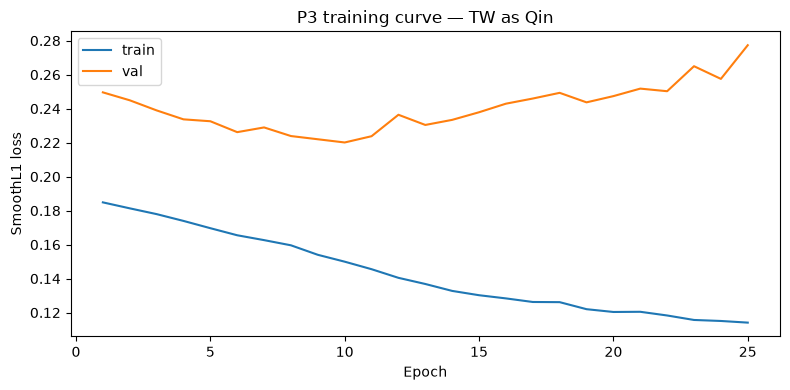

Saved training history to: outputs\problem4_with_p3_feb_forecast\p3_TW_Qin\baseline\training_history.xlsx


In [7]:
# =========================
# 5. Dataset, model, training
# =========================

class SequenceDataset(Dataset):
    def __init__(self, X, y, mask):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx]

train_loader = DataLoader(SequenceDataset(X_train, y_train, mask_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SequenceDataset(X_val, y_val, mask_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SequenceDataset(X_test, y_test, mask_test), batch_size=BATCH_SIZE, shuffle=False)

class ResidualGRU(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.1, output_size=6):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_hidden = gru_out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)

model = ResidualGRU(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=HORIZON,
).to(device)

criterion = nn.SmoothL1Loss(reduction="none")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(model)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    observed_total = 0.0

    for xb, yb, mb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        mb = mb.to(device)

        if is_train:
            optimizer.zero_grad()

        pred = model(xb)
        element_loss = criterion(pred, yb)
        observed_count = mb.sum()
        if observed_count.item() == 0:
            continue
        loss = (element_loss * mb).sum() / observed_count

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_loss += loss.item() * observed_count.item()
        observed_total += observed_count.item()

    return total_loss / max(observed_total, 1.0)

best_val_loss = float("inf")
best_state = None
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)

    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.6f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.xlsx"
history_df.to_excel(history_path, index=False)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title(f"P3 training curve — {QIN_MODE} as Qin")
plt.legend()
plt.tight_layout()
plt.show()

print("Saved training history to:", history_path)

In [8]:
# =========================
# 6. Evaluation
# =========================

def predict_loader(model, loader):
    model.eval()
    preds, trues, masks = [], [], []

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
            masks.append(mb.numpy())

    return np.vstack(preds), np.vstack(trues), np.vstack(masks).astype(bool)

def safe_corr(a, b, method="pearson"):
    a = pd.Series(np.asarray(a).reshape(-1))
    b = pd.Series(np.asarray(b).reshape(-1))
    valid = a.notna() & b.notna()
    a = a[valid]
    b = b[valid]
    if len(a) < 3:
        return np.nan
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return a.corr(b, method=method)

def direction_accuracy(true_delta, pred_delta):
    true_s = np.sign(np.asarray(true_delta).reshape(-1))
    pred_s = np.sign(np.asarray(pred_delta).reshape(-1))
    return np.mean(true_s == pred_s)

def build_metrics(y_true_ntu, y_pred_ntu, y_true_delta, y_pred_delta, observed_mask, model_name):
    rows = []

    for i, hour in enumerate(HORIZON_HOURS):
        valid = observed_mask[:, i]
        yt = y_true_ntu[valid, i]
        yp = y_pred_ntu[valid, i]
        dt = y_true_delta[valid, i]
        dp = y_pred_delta[valid, i]

        rows.append({
            "qin_mode": QIN_MODE,
            "model": model_name,
            "horizon": f"t+{i+1}",
            "horizon_hour": hour,
            "observed_count": int(valid.sum()),
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": math.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
            "NTU_Pearson": safe_corr(yt, yp, "pearson"),
            "NTU_Spearman": safe_corr(yt, yp, "spearman"),
            "Delta_Pearson": safe_corr(dt, dp, "pearson"),
            "Delta_Spearman": safe_corr(dt, dp, "spearman"),
            "Direction_Accuracy": direction_accuracy(dt, dp),
        })

    valid_flat = observed_mask.reshape(-1)
    y_true_ntu_flat = y_true_ntu.reshape(-1)[valid_flat]
    y_pred_ntu_flat = y_pred_ntu.reshape(-1)[valid_flat]
    y_true_delta_flat = y_true_delta.reshape(-1)[valid_flat]
    y_pred_delta_flat = y_pred_delta.reshape(-1)[valid_flat]

    rows.append({
        "qin_mode": QIN_MODE,
        "model": model_name,
        "horizon": "overall",
        "horizon_hour": "2-12",
        "observed_count": int(valid_flat.sum()),
        "MAE": mean_absolute_error(y_true_ntu_flat, y_pred_ntu_flat),
        "RMSE": math.sqrt(mean_squared_error(y_true_ntu_flat, y_pred_ntu_flat)),
        "R2": r2_score(y_true_ntu_flat, y_pred_ntu_flat),
        "NTU_Pearson": safe_corr(y_true_ntu_flat, y_pred_ntu_flat, "pearson"),
        "NTU_Spearman": safe_corr(y_true_ntu_flat, y_pred_ntu_flat, "spearman"),
        "Delta_Pearson": safe_corr(y_true_delta_flat, y_pred_delta_flat, "pearson"),
        "Delta_Spearman": safe_corr(y_true_delta_flat, y_pred_delta_flat, "spearman"),
        "Direction_Accuracy": direction_accuracy(y_true_delta_flat, y_pred_delta_flat),
    })

    return pd.DataFrame(rows)

y_pred_delta_scaled, y_true_delta_scaled, y_observed_mask = predict_loader(model, test_loader)

pred_delta_gru = inverse_delta(y_pred_delta_scaled)
true_delta = inverse_delta(y_true_delta_scaled)

true_ntu = current_test.reshape(-1, 1) + true_delta
pred_ntu_gru = current_test.reshape(-1, 1) + pred_delta_gru
pred_ntu_gru = np.clip(pred_ntu_gru, 0, None)

pred_delta_persistence = np.zeros_like(true_delta)
pred_ntu_persistence = np.repeat(current_test.reshape(-1, 1), HORIZON, axis=1)
pred_ntu_persistence = np.clip(pred_ntu_persistence, 0, None)

metrics_persistence = build_metrics(true_ntu, pred_ntu_persistence, true_delta, pred_delta_persistence, y_observed_mask, "Persistence")
metrics_gru = build_metrics(true_ntu, pred_ntu_gru, true_delta, pred_delta_gru, y_observed_mask, f"Formula_Residual_GRU_Clip2_{FEATURE_VARIANT}")

metrics_comparison_df = pd.concat([metrics_persistence, metrics_gru], axis=0).reset_index(drop=True)

display(metrics_comparison_df)

metrics_path = OUTPUT_DIR / "metrics_comparison.xlsx"
metrics_comparison_df.to_excel(metrics_path, index=False)
print("Saved metrics to:", metrics_path)

rows = []
for sample_idx in range(len(current_test)):
    for h_idx, hour in enumerate(HORIZON_HOURS):
        rows.append({
            "qin_mode": QIN_MODE,
            "sample_idx": sample_idx,
            "base_time": pd.Timestamp(base_test_times[sample_idx]),
            "target_time": pd.Timestamp(target_test_times[sample_idx, h_idx]),
            "horizon": f"t+{h_idx+1}",
            "horizon_hour": hour,
            "current_NTU": current_test[sample_idx],
            "target_observed": bool(y_observed_mask[sample_idx, h_idx]),
            "true_NTU": true_ntu[sample_idx, h_idx] if y_observed_mask[sample_idx, h_idx] else np.nan,
            "true_delta_NTU": true_delta[sample_idx, h_idx] if y_observed_mask[sample_idx, h_idx] else np.nan,
            "pred_NTU_gru": pred_ntu_gru[sample_idx, h_idx],
            "pred_delta_gru": pred_delta_gru[sample_idx, h_idx],
            "pred_NTU_persistence": pred_ntu_persistence[sample_idx, h_idx],
            "pred_delta_persistence": 0.0,
        })

test_predictions_df = pd.DataFrame(rows)
display(test_predictions_df.head())

test_pred_path = OUTPUT_DIR / "test_predictions_long.xlsx"
test_predictions_df.to_excel(test_pred_path, index=False)
print("Saved test predictions to:", test_pred_path)

,qin_mode,model,horizon,horizon_hour,observed_count,MAE,RMSE,R2,NTU_Pearson,NTU_Spearman,Delta_Pearson,Delta_Spearman,Direction_Accuracy
0,TW,Persistence,t+1,2,465,0.018495,0.082754,0.814184,0.906990,0.979511,NaN,NaN,0.520430
1,TW,Persistence,t+2,4,464,0.031034,0.117450,0.626470,0.812842,0.954777,NaN,NaN,0.340517
2,TW,Persistence,t+3,6,463,0.036397,0.123273,0.589393,0.794049,0.935789,NaN,NaN,0.259179
3,TW,Persistence,t+4,8,462,0.036260,0.112505,0.658880,0.828729,0.923179,NaN,NaN,0.212121
4,TW,Persistence,t+5,10,461,0.037531,0.108362,0.684376,0.841370,0.910164,NaN,NaN,0.208243
5,TW,Persistence,t+6,12,460,0.044591,0.127858,0.562052,0.779597,0.891559,NaN,NaN,0.176087
6,TW,Persistence,overall,2-12,2775,0.034025,0.112948,0.655868,0.827294,0.932609,NaN,NaN,0.286486
7,TW,Formula_Residual_GRU_Clip2_baseline,t+1,2,465,0.021463,0.080296,0.825055,0.912472,0.977907,0.261096,0.092916,0.253763
8,TW,Formula_Residual_GRU_Clip2_baseline,t+2,4,464,0.032020,0.110208,0.671113,0.830410,0.951393,0.380679,0.214485,0.387931
9,TW,Formula_Residual_GRU_Clip2_baseline,t+3,6,463,0.036270,0.114003,0.648826,0.815078,0.932867,0.410817,0.262756,0.455724


Saved metrics to: outputs\problem4_with_p3_feb_forecast\p3_TW_Qin\baseline\metrics_comparison.xlsx


,qin_mode,sample_idx,base_time,target_time,horizon,horizon_hour,current_NTU,target_observed,true_NTU,true_delta_NTU,pred_NTU_gru,pred_delta_gru,pred_NTU_persistence,pred_delta_persistence
0,TW,0,2026-01-23 23:00:00,2026-01-24 01:00:00,t+1,2,0.28,True,0.28,0.00,0.276850,-0.003150,0.28,0.0
1,TW,0,2026-01-23 23:00:00,2026-01-24 03:00:00,t+2,4,0.28,True,0.27,-0.01,0.280113,0.000113,0.28,0.0
2,TW,0,2026-01-23 23:00:00,2026-01-24 05:00:00,t+3,6,0.28,True,0.27,-0.01,0.280510,0.000510,0.28,0.0
3,TW,0,2026-01-23 23:00:00,2026-01-24 07:00:00,t+4,8,0.28,True,0.27,-0.01,0.284970,0.004970,0.28,0.0
4,TW,0,2026-01-23 23:00:00,2026-01-24 09:00:00,t+5,10,0.28,True,0.27,-0.01,0.282197,0.002197,0.28,0.0


Saved test predictions to: outputs\problem4_with_p3_feb_forecast\p3_TW_Qin\baseline\test_predictions_long.xlsx


## A. Generate February NTU forecast by P3 model

本节使用已经训练好的 P3 TW-Qin residual GRU 模型预测 2026 年 2 月运行日所需的出厂水 NTU。

预测方式采用递推的 6h block rolling：

```text
base time → predict t+2, t+4, t+6
将预测值写回 NTU 历史状态
base time 移动到 t+6
继续预测下一段
```

预测区间设为：

```text
2026-02-01 07:00 至 2026-03-01 05:00
```

这样可以覆盖完整 2 月运行日。因为运行日定义为当日 07:00 至次日 05:00，所以 2026-02-28 的运行日需要包含 2026-03-01 01:00、03:00、05:00。

In [9]:
# =========================
# A. P3 rolling forecast for February NTU
# =========================

FEB_FORECAST_START = pd.Timestamp("2026-02-01 07:00")
FEB_FORECAST_END = pd.Timestamp("2026-03-01 05:00")
P4_TARGET_COL = "P4_NTU"

forecast_work = data_pre.copy()
forecast_work["DATETIME"] = pd.to_datetime(forecast_work["DATETIME"]).dt.floor("min")
forecast_work = forecast_work.sort_values("DATETIME").reset_index(drop=True)

time_to_pos_p3 = {
    pd.Timestamp(t).floor("min"): i
    for i, t in enumerate(forecast_work["DATETIME"])
}

raw_cols_for_recompute = list(dict.fromkeys([
    "DATETIME", TARGET, "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"
]))

def recompute_p3_formula_features(raw_block):
    # Recompute the same P3 formula-term features after predicted NTU values
    # are recursively written back into the target column.
    df = raw_block.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"]).dt.floor("min")

    for c in [TARGET, "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").ffill().bfill()

    well_level = df["C/W WELL LEVEL"].astype(float)
    well_level_safe = well_level.abs().where(well_level.abs() > EPS).ffill().bfill().fillna(1.0) + EPS

    current_ntu = df[TARGET].astype(float)
    filt_ntu = df["FILT. NTU"].astype(float)
    rw_flow = df["R/W FLOW"].astype(float)
    tw_flow = df["T/W FLOW"].astype(float)

    qin = rw_flow if QIN_MODE == "RW" else tw_flow
    qout = tw_flow

    df["current_NTU"] = current_ntu
    df["InLoad"] = qin * filt_ntu
    df["OutLoad"] = qout * current_ntu
    df["NetLoad"] = df["InLoad"] - df["OutLoad"]
    df["inflow_term"] = DT_HOURS * qin * filt_ntu / well_level_safe
    df["outflow_term"] = DT_HOURS * qout * current_ntu / well_level_safe
    df["HRT_PROXY"] = well_level_safe / (qout.abs() + EPS)
    df["ReplaceRate"] = qout / well_level_safe
    df["DeltaC_PROXY"] = df["NetLoad"] / well_level_safe
    df["WELL_LEVEL_CHANGE"] = well_level.diff().fillna(0.0)

    return df

def predict_block_from_base_position(base_pos):
    # Predict [t+2h, t+4h, t+6h] from a base position.
    # The model itself may output 6 horizons; for February recursive filling
    # only the first three short-horizon outputs are used.
    start_pos = base_pos - LOOKBACK + 1
    if start_pos < 0:
        raise ValueError("Not enough history for February rolling forecast.")

    context_start = max(0, start_pos - 1)
    raw_block = forecast_work.iloc[context_start:base_pos + 1][raw_cols_for_recompute].copy()
    feature_block = recompute_p3_formula_features(raw_block).iloc[-LOOKBACK:].copy()

    x_scaled = feature_scaler.transform(feature_block[FEATURES]).astype(np.float32)
    x_tensor = torch.tensor(x_scaled[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_delta_scaled = model(x_tensor).cpu().numpy()

    pred_delta = inverse_delta(pred_delta_scaled)[0]
    current_c = float(feature_block.iloc[-1]["current_NTU"])

    pred_ntu_2_6 = np.clip(current_c + pred_delta[:3], 0, None)
    return pred_ntu_2_6, current_c

def generate_february_forecast():
    if FEB_FORECAST_START not in time_to_pos_p3:
        raise KeyError(f"FEB_FORECAST_START not found in data: {FEB_FORECAST_START}")

    base_time = FEB_FORECAST_START - pd.Timedelta(hours=2)
    if base_time not in time_to_pos_p3:
        raise KeyError(f"Initial base time not found in data: {base_time}")

    rows = []
    current_base = base_time

    while current_base < FEB_FORECAST_END:
        if current_base not in time_to_pos_p3:
            rows.append({
                "base_time": current_base,
                "ok": False,
                "reason": "base_time missing in data grid",
            })
            break

        base_pos = time_to_pos_p3[current_base]
        try:
            pred_2_6, current_c = predict_block_from_base_position(base_pos)
        except Exception as e:
            rows.append({
                "base_time": current_base,
                "ok": False,
                "reason": str(e),
            })
            break

        for k, hour in enumerate([2, 4, 6]):
            target_time = current_base + pd.Timedelta(hours=hour)
            if target_time > FEB_FORECAST_END:
                continue
            if target_time not in time_to_pos_p3:
                rows.append({
                    "base_time": current_base,
                    "target_time": target_time,
                    "horizon_hour": hour,
                    "ok": False,
                    "reason": "target_time missing in data grid",
                })
                continue

            pred_value = float(pred_2_6[k])
            target_pos = time_to_pos_p3[target_time]

            forecast_work.loc[target_pos, TARGET] = pred_value

            rows.append({
                "base_time": current_base,
                "target_time": target_time,
                "horizon_hour": hour,
                "current_NTU_at_base": current_c,
                "predicted_NTU": pred_value,
                "ok": True,
                "reason": "",
            })

        current_base = current_base + pd.Timedelta(hours=6)

    return pd.DataFrame(rows)

february_forecast_long = generate_february_forecast()

display(february_forecast_long.head(20))
print("February forecast rows:", len(february_forecast_long))
print("Successful forecast rows:", int(february_forecast_long["ok"].fillna(False).sum()))
print("Forecast range:", february_forecast_long["target_time"].min(), "to", february_forecast_long["target_time"].max())

p4_source_data = data[["DATETIME", "DATE", "TIME", TARGET]].copy()
p4_source_data["DATETIME"] = pd.to_datetime(p4_source_data["DATETIME"]).dt.floor("min")
p4_source_data[TARGET] = pd.to_numeric(p4_source_data[TARGET], errors="coerce")
p4_source_data[P4_TARGET_COL] = p4_source_data[TARGET]
p4_source_data["P4_NTU_SOURCE"] = "observed"

successful_forecast = february_forecast_long[february_forecast_long["ok"] == True].copy()
forecast_map = successful_forecast.set_index("target_time")["predicted_NTU"].to_dict()

replace_mask = p4_source_data["DATETIME"].between(FEB_FORECAST_START, FEB_FORECAST_END)
p4_source_data.loc[replace_mask, P4_TARGET_COL] = p4_source_data.loc[replace_mask, "DATETIME"].map(forecast_map)
p4_source_data.loc[replace_mask, "P4_NTU_SOURCE"] = "P3_forecast"

feb_missing_after_replace = p4_source_data.loc[replace_mask, P4_TARGET_COL].isna().sum()

p4_input_audit = pd.DataFrame({
    "item": [
        "feb_forecast_start",
        "feb_forecast_end",
        "p3_successful_forecast_points",
        "february_rows_in_p4_input",
        "february_missing_after_forecast",
        "observed_rows_outside_february",
        "p4_target_column",
    ],
    "value": [
        FEB_FORECAST_START,
        FEB_FORECAST_END,
        int(successful_forecast.shape[0]),
        int(replace_mask.sum()),
        int(feb_missing_after_replace),
        int((p4_source_data["P4_NTU_SOURCE"] == "observed").sum()),
        P4_TARGET_COL,
    ],
})

display(p4_input_audit)
display(p4_source_data.loc[replace_mask, ["DATETIME", TARGET, P4_TARGET_COL, "P4_NTU_SOURCE"]].head(20))

,base_time,target_time,horizon_hour,current_NTU_at_base,predicted_NTU,ok,reason
0,2026-02-01 05:00:00,2026-02-01 07:00:00,2,0.320000,0.324486,True,
1,2026-02-01 05:00:00,2026-02-01 09:00:00,4,0.320000,0.333604,True,
2,2026-02-01 05:00:00,2026-02-01 11:00:00,6,0.320000,0.332417,True,
3,2026-02-01 11:00:00,2026-02-01 13:00:00,2,0.332417,0.338833,True,
4,2026-02-01 11:00:00,2026-02-01 15:00:00,4,0.332417,0.344072,True,
5,2026-02-01 11:00:00,2026-02-01 17:00:00,6,0.332417,0.337084,True,
6,2026-02-01 17:00:00,2026-02-01 19:00:00,2,0.337084,0.316192,True,
7,2026-02-01 17:00:00,2026-02-01 21:00:00,4,0.337084,0.306214,True,
8,2026-02-01 17:00:00,2026-02-01 23:00:00,6,0.337084,0.301342,True,
9,2026-02-01 23:00:00,2026-02-02 01:00:00,2,0.301342,0.302748,True,


February forecast rows: 336
Successful forecast rows: 336
Forecast range: 2026-02-01 07:00:00 to 2026-03-01 05:00:00


,item,value
0,feb_forecast_start,2026-02-01 07:00:00
1,feb_forecast_end,2026-03-01 05:00:00
2,p3_successful_forecast_points,336
3,february_rows_in_p4_input,336
4,february_missing_after_forecast,0
5,observed_rows_outside_february,5124
6,p4_target_column,P4_NTU


,DATETIME,NTU,P4_NTU,P4_NTU_SOURCE
4752,2026-02-01 07:00:00,NaN,0.324486,P3_forecast
4753,2026-02-01 09:00:00,NaN,0.333604,P3_forecast
4754,2026-02-01 11:00:00,NaN,0.332417,P3_forecast
4755,2026-02-01 13:00:00,NaN,0.338833,P3_forecast
4756,2026-02-01 15:00:00,NaN,0.344072,P3_forecast
4757,2026-02-01 17:00:00,NaN,0.337084,P3_forecast
4758,2026-02-01 19:00:00,NaN,0.316192,P3_forecast
4759,2026-02-01 21:00:00,NaN,0.306214,P3_forecast
4760,2026-02-01 23:00:00,NaN,0.301342,P3_forecast
4761,2026-02-02 01:00:00,NaN,0.302748,P3_forecast


# P4 OR-risk pipeline using P3-forecasted February NTU

下面开始运行原 P4 的 OR-risk 过程。除输入 `NTU` 改为 `P4_NTU` 外，风险指标、归一化、OR 评分、四级分类和 NTU 硬约束均保持原方法不变。

## 1. 依赖与参数

In [10]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

TARGET_COL = P4_TARGET_COL  # February uses P3 forecast; other months use observed NTU
STANDARD_LIMIT = 1.0
WARNING_LEVEL = 0.7
EXPECTED_POINTS_PER_DAY = 12
MIN_VALID_POINTS = 6
EXPECTED_INTERVAL = pd.Timedelta(hours=2)

Q1_START = pd.Timestamp("2026-01-01")
Q1_END = pd.Timestamp("2026-03-31")
MARCH_START = pd.Timestamp("2026-03-01")
MARCH_END = pd.Timestamp("2026-03-31")

RISK_CAPS = {
    "max_excess": 4.0,
    "exceed_ratio": 0.50,
    "median_excess": 0.50,
    "ntu_std": 0.50,
    "longest_rising_steps": 4.0,
}

RAW_INDICATORS = list(RISK_CAPS)
NORMALIZED_INDICATORS = [f"r_{name}" for name in RAW_INDICATORS]

def locate_project_root():
    cwd = Path.cwd().resolve()
    for root in [cwd] + list(cwd.parents):
        if (root / "data" / "merged.xlsx").exists():
            return root
    raise FileNotFoundError("未找到 data/merged.xlsx，请从项目目录或其子目录运行。")

PROJECT_ROOT = locate_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "merged.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "codes" / "p4" / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCEL_PATH = OUTPUT_DIR / "problem4_OR_with_P3_feb_forecast.xlsx"
print("项目目录：", PROJECT_ROOT)
print("数据文件：", DATA_PATH)
print("Excel 输出：", EXCEL_PATH)


项目目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup
数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
Excel 输出： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\p4\outputs\problem4_OR_with_P3_feb_forecast.xlsx


## 2. 读取原始 NTU 并构造运行日

将 `DATE + TIME` 组合为实际时间。凌晨 `01:00、03:00、05:00` 归入前一个运行日，
从而保证一个完整运行日对应 `07:00` 至次日 `05:00`。

In [11]:
# Use the P3-augmented P4 input table instead of reading NTU directly from merged.xlsx.
raw = p4_source_data.copy()

required_cols = {"DATE", "TIME", TARGET_COL}
missing_cols = required_cols.difference(raw.columns)
if missing_cols:
    raise ValueError(f"缺少必要字段：{sorted(missing_cols)}")

data = raw[["DATE", "TIME", "DATETIME", TARGET_COL, "P4_NTU_SOURCE"]].copy()
data["DATE"] = pd.to_datetime(data["DATE"], errors="coerce").dt.normalize()

# DATETIME has already been reconstructed by P3. Keep it as the authoritative timestamp.
data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce").dt.floor("min")
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors="coerce")
data = data.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

data["OP_DATE"] = data["DATETIME"].dt.normalize()
before_seven = data["DATETIME"].dt.hour < 7
data.loc[before_seven, "OP_DATE"] = (
    data.loc[before_seven, "DATETIME"] - pd.Timedelta(days=1)
).dt.normalize()

source_audit = pd.DataFrame({
    "item": [
        "source_rows", "source_datetime_start", "source_datetime_end",
        "operation_date_start", "operation_date_end", "valid_P4_NTU_points",
        "missing_P4_NTU_points", "P4_NTU_above_1_points", "maximum_P4_NTU",
        "P3_forecast_rows_used", "observed_rows_used"
    ],
    "value": [
        len(data), data["DATETIME"].min(), data["DATETIME"].max(),
        data["OP_DATE"].min(), data["OP_DATE"].max(),
        data[TARGET_COL].notna().sum(), data[TARGET_COL].isna().sum(),
        (data[TARGET_COL] > STANDARD_LIMIT).sum(), data[TARGET_COL].max(),
        int((data["P4_NTU_SOURCE"] == "P3_forecast").sum()),
        int((data["P4_NTU_SOURCE"] == "observed").sum()),
    ]
})

display(source_audit)
display(data[["DATETIME", "OP_DATE", TARGET_COL, "P4_NTU_SOURCE"]].head(15))

,item,value
0,source_rows,5460
1,source_datetime_start,2025-01-01 07:00:00
2,source_datetime_end,2026-04-01 05:00:00
3,operation_date_start,2025-01-01 00:00:00
4,operation_date_end,2026-03-31 00:00:00
5,valid_P4_NTU_points,5460
6,missing_P4_NTU_points,0
7,P4_NTU_above_1_points,179
8,maximum_P4_NTU,11.9000
9,P3_forecast_rows_used,336


,DATETIME,OP_DATE,P4_NTU,P4_NTU_SOURCE
0,2025-01-01 07:00:00,2025-01-01,0.1200,observed
1,2025-01-01 09:00:00,2025-01-01,0.1200,observed
2,2025-01-01 11:00:00,2025-01-01,0.1200,observed
3,2025-01-01 13:00:00,2025-01-01,0.1100,observed
4,2025-01-01 15:00:00,2025-01-01,0.1100,observed
5,2025-01-01 17:00:00,2025-01-01,0.1100,observed
6,2025-01-01 19:00:00,2025-01-01,0.1100,observed
7,2025-01-01 21:00:00,2025-01-01,0.1100,observed
8,2025-01-01 23:00:00,2025-01-01,0.1200,observed
9,2025-01-02 01:00:00,2025-01-01,0.1200,observed


## 3. 五维日风险向量

每日原始指标为：

1. `max_excess`：最大超标幅度；
2. `exceed_ratio`：有效观测点中的超标点占比；
3. `median_excess`：仅在超标点上计算的 `NTU-1` 中位数；
4. `ntu_std`：每日 NTU 总体标准差（`ddof=0`）；
5. `longest_rising_steps`：相邻点均大于 `0.7`、时间差恰为 2 小时且持续上升的最长比较步数。

连续上升遇到缺测、时间缺口、下降或任一点不高于 `0.7` 时立即重置。

In [12]:
def longest_rising_steps(group, warning_level=WARNING_LEVEL):
    ordered = group.sort_values("DATETIME")[["DATETIME", TARGET_COL]]
    times = ordered["DATETIME"].tolist()
    values = ordered[TARGET_COL].tolist()

    best = 0
    current = 0
    for index in range(1, len(ordered)):
        previous_value = values[index - 1]
        current_value = values[index]
        exact_interval = (times[index] - times[index - 1]) == EXPECTED_INTERVAL
        valid_pair = pd.notna(previous_value) and pd.notna(current_value)
        rising_above_warning = (
            valid_pair
            and previous_value > warning_level
            and current_value > warning_level
            and current_value > previous_value
        )
        if exact_interval and rising_above_warning:
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best


def summarize_operation_day(op_date, group):
    valid_values = group[TARGET_COL].dropna()
    n_valid = len(valid_values)
    coverage = n_valid / EXPECTED_POINTS_PER_DAY
    can_score = n_valid >= MIN_VALID_POINTS

    result = {
        "OP_DATE": pd.Timestamp(op_date),
        "n_expected": EXPECTED_POINTS_PER_DAY,
        "n_valid": n_valid,
        "data_coverage": coverage,
        "is_complete_day": n_valid == EXPECTED_POINTS_PER_DAY,
        "can_score": can_score,
        "data_status": (
            "完整可评分" if n_valid == EXPECTED_POINTS_PER_DAY
            else "不完整但可评分" if can_score
            else "有效点不足，不评分"
        ),
    }

    if n_valid == 0:
        result.update({
            "mean_NTU": np.nan, "max_NTU": np.nan, "min_NTU": np.nan,
            "max_excess": np.nan, "exceed_ratio": np.nan,
            "median_excess": np.nan, "ntu_std": np.nan,
            "longest_rising_steps": np.nan,
        })
        return result

    excess = (valid_values - STANDARD_LIMIT).clip(lower=0)
    positive_excess = excess[excess > 0]
    result.update({
        "mean_NTU": valid_values.mean(),
        "max_NTU": valid_values.max(),
        "min_NTU": valid_values.min(),
        "max_excess": excess.max(),
        "exceed_ratio": (valid_values > STANDARD_LIMIT).mean(),
        "median_excess": positive_excess.median() if len(positive_excess) else 0.0,
        "ntu_std": valid_values.std(ddof=0),
        "longest_rising_steps": longest_rising_steps(group),
    })
    return result

In [13]:
observed_daily = pd.DataFrame([
    summarize_operation_day(op_date, group)
    for op_date, group in data.groupby("OP_DATE", sort=True)
])

full_calendar = pd.DataFrame({
    "OP_DATE": pd.date_range(
        observed_daily["OP_DATE"].min(),
        observed_daily["OP_DATE"].max(),
        freq="D"
    )
})
daily = full_calendar.merge(observed_daily, on="OP_DATE", how="left")

no_rows = daily["n_valid"].isna()
daily.loc[no_rows, "n_expected"] = EXPECTED_POINTS_PER_DAY
daily.loc[no_rows, "n_valid"] = 0
daily.loc[no_rows, "data_coverage"] = 0.0
daily.loc[no_rows, "is_complete_day"] = False
daily.loc[no_rows, "can_score"] = False
daily.loc[no_rows, "data_status"] = "无观测记录，不评分"

daily["n_expected"] = daily["n_expected"].astype(int)
daily["n_valid"] = daily["n_valid"].astype(int)
daily["is_complete_day"] = daily["is_complete_day"].astype(bool)
daily["can_score"] = daily["can_score"].astype(bool)

display(daily.head())
print("全历史日历日：", len(daily))
print("可评分运行日：", int(daily["can_score"].sum()))
print("完整运行日：", int(daily["is_complete_day"].sum()))

,OP_DATE,n_expected,n_valid,data_coverage,is_complete_day,can_score,data_status,mean_NTU,max_NTU,min_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps
0,2025-01-01,12,12,1.0000,True,True,完整可评分,0.1158,0.1200,0.1100,0.0000,0.0000,0.0000,0.0049,0
1,2025-01-02,12,12,1.0000,True,True,完整可评分,0.1183,0.1300,0.1000,0.0000,0.0000,0.0000,0.0099,0
2,2025-01-03,12,12,1.0000,True,True,完整可评分,0.1175,0.1300,0.1100,0.0000,0.0000,0.0000,0.0072,0
3,2025-01-04,12,12,1.0000,True,True,完整可评分,0.1250,0.1500,0.1100,0.0000,0.0000,0.0000,0.0112,0
4,2025-01-05,12,12,1.0000,True,True,完整可评分,0.1200,0.1300,0.1100,0.0000,0.0000,0.0000,0.0071,0


全历史日历日： 455
可评分运行日： 455
完整运行日： 455


## 4. 固定上限归一化与概率和 OR

每项指标按固定风险上限映射并截断：

\[
r_i=\min\left(\frac{x_i}{c_i},1\right)
\]

固定上限依次为 `1.0 NTU、0.50、0.5 NTU、0.5 NTU、4 步`。
只有有效点不少于 6 的运行日计算综合评分。

In [14]:
for indicator, cap in RISK_CAPS.items():
    normalized_col = f"r_{indicator}"
    daily[normalized_col] = np.where(
        daily["can_score"],
        (daily[indicator] / cap).clip(lower=0, upper=1),
        np.nan,
    )

daily["OR_risk_score"] = np.where(
    daily["can_score"],
    1.0 - np.prod(1.0 - daily[NORMALIZED_INDICATORS], axis=1),
    np.nan,
)

score_columns = [
    "OP_DATE", "data_status", "n_expected", "n_valid", "data_coverage",
    "is_complete_day", "can_score", "mean_NTU", "max_NTU", "min_NTU",
    *RAW_INDICATORS, *NORMALIZED_INDICATORS, "OR_risk_score",
]
daily_scores = daily[score_columns].copy()

display(daily_scores.loc[daily_scores["can_score"]].head())
display(daily_scores["OR_risk_score"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
))

,OP_DATE,data_status,n_expected,n_valid,data_coverage,is_complete_day,can_score,mean_NTU,max_NTU,min_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps,r_max_excess,r_exceed_ratio,r_median_excess,r_ntu_std,r_longest_rising_steps,OR_risk_score
0,2025-01-01,完整可评分,12,12,1.0000,True,True,0.1158,0.1200,0.1100,0.0000,0.0000,0.0000,0.0049,0,0.0000,0.0000,0.0000,0.0099,0.0000,0.0099
1,2025-01-02,完整可评分,12,12,1.0000,True,True,0.1183,0.1300,0.1000,0.0000,0.0000,0.0000,0.0099,0,0.0000,0.0000,0.0000,0.0197,0.0000,0.0197
2,2025-01-03,完整可评分,12,12,1.0000,True,True,0.1175,0.1300,0.1100,0.0000,0.0000,0.0000,0.0072,0,0.0000,0.0000,0.0000,0.0144,0.0000,0.0144
3,2025-01-04,完整可评分,12,12,1.0000,True,True,0.1250,0.1500,0.1100,0.0000,0.0000,0.0000,0.0112,0,0.0000,0.0000,0.0000,0.0224,0.0000,0.0224
4,2025-01-05,完整可评分,12,12,1.0000,True,True,0.1200,0.1300,0.1100,0.0000,0.0000,0.0000,0.0071,0,0.0000,0.0000,0.0000,0.0141,0.0000,0.0141


count   455.0000
mean      0.1502
std       0.2713
min       0.0000
25%       0.0217
50%       0.0369
75%       0.0999
90%       0.5074
95%       0.9905
99%       1.0000
max       1.0000
Name: OR_risk_score, dtype: float64

## 5. 2026 年第一季度与 3 月结果

In [15]:
q1_calendar = pd.DataFrame({"OP_DATE": pd.date_range(Q1_START, Q1_END, freq="D")})
q1 = q1_calendar.merge(daily_scores, on="OP_DATE", how="left")

q1_missing = q1["data_status"].isna()
q1.loc[q1_missing, "data_status"] = "无观测记录，不评分"
q1.loc[q1_missing, "n_expected"] = EXPECTED_POINTS_PER_DAY
q1.loc[q1_missing, "n_valid"] = 0
q1.loc[q1_missing, "data_coverage"] = 0.0
q1.loc[q1_missing, "is_complete_day"] = False
q1.loc[q1_missing, "can_score"] = False

march = q1[q1["OP_DATE"].between(MARCH_START, MARCH_END)].copy()

q1_summary = pd.DataFrame({
    "item": [
        "calendar_days", "scored_days", "unscored_days",
        "complete_days", "partial_scored_days", "score_mean",
        "score_median", "score_max"
    ],
    "value": [
        len(q1), q1["OR_risk_score"].notna().sum(),
        q1["OR_risk_score"].isna().sum(),
        q1["is_complete_day"].fillna(False).sum(),
        ((q1["can_score"] == True) & (q1["is_complete_day"] == False)).sum(),
        q1["OR_risk_score"].mean(), q1["OR_risk_score"].median(),
        q1["OR_risk_score"].max()
    ]
})

display(q1_summary)
display(march)

,item,value
0,calendar_days,90.0000
1,scored_days,90.0000
2,unscored_days,0.0000
3,complete_days,90.0000
4,partial_scored_days,0.0000
5,score_mean,0.0874
6,score_median,0.0269
7,score_max,1.0000


,OP_DATE,data_status,n_expected,n_valid,data_coverage,is_complete_day,can_score,mean_NTU,max_NTU,min_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps,r_max_excess,r_exceed_ratio,r_median_excess,r_ntu_std,r_longest_rising_steps,OR_risk_score
59,2026-03-01,完整可评分,12,12,1.0000,True,True,0.4525,0.4800,0.4200,0.0000,0.0000,0.0000,0.0159,0,0.0000,0.0000,0.0000,0.0318,0.0000,0.0318
60,2026-03-02,完整可评分,12,12,1.0000,True,True,0.4733,0.4900,0.4500,0.0000,0.0000,0.0000,0.0149,0,0.0000,0.0000,0.0000,0.0298,0.0000,0.0298
61,2026-03-03,完整可评分,12,12,1.0000,True,True,0.4933,0.5100,0.4700,0.0000,0.0000,0.0000,0.0137,0,0.0000,0.0000,0.0000,0.0275,0.0000,0.0275
62,2026-03-04,完整可评分,12,12,1.0000,True,True,0.5017,0.5200,0.4800,0.0000,0.0000,0.0000,0.0162,0,0.0000,0.0000,0.0000,0.0325,0.0000,0.0325
63,2026-03-05,完整可评分,12,12,1.0000,True,True,0.5308,0.5600,0.5100,0.0000,0.0000,0.0000,0.0166,0,0.0000,0.0000,0.0000,0.0331,0.0000,0.0331
64,2026-03-06,完整可评分,12,12,1.0000,True,True,0.5400,0.5600,0.5200,0.0000,0.0000,0.0000,0.0091,0,0.0000,0.0000,0.0000,0.0183,0.0000,0.0183
65,2026-03-07,完整可评分,12,12,1.0000,True,True,0.5250,0.5400,0.5100,0.0000,0.0000,0.0000,0.0112,0,0.0000,0.0000,0.0000,0.0224,0.0000,0.0224
66,2026-03-08,完整可评分,12,12,1.0000,True,True,0.5367,0.5600,0.5200,0.0000,0.0000,0.0000,0.0137,0,0.0000,0.0000,0.0000,0.0275,0.0000,0.0275
67,2026-03-09,完整可评分,12,12,1.0000,True,True,0.5442,0.5600,0.5300,0.0000,0.0000,0.0000,0.0095,0,0.0000,0.0000,0.0000,0.0191,0.0000,0.0191
68,2026-03-10,完整可评分,12,12,1.0000,True,True,0.5392,0.5500,0.5300,0.0000,0.0000,0.0000,0.0076,0,0.0000,0.0000,0.0000,0.0152,0.0000,0.0152


## 6. 全部历史数据连续蜂群图

- 每个点代表全部历史范围内的一个可评分运行日；
- 纵轴为精确 OR 综合评分；
- 横向位置仅用于避免点重叠和展示局部密度，不表示数值；
- 颜色表示每日最大 NTU，色条上的黑色标记对应国标限值 `1 NTU`；
- 缺失或有效点不足日期不会按零分绘制；
- 图仅在 notebook 中展示，不另存为图片文件。

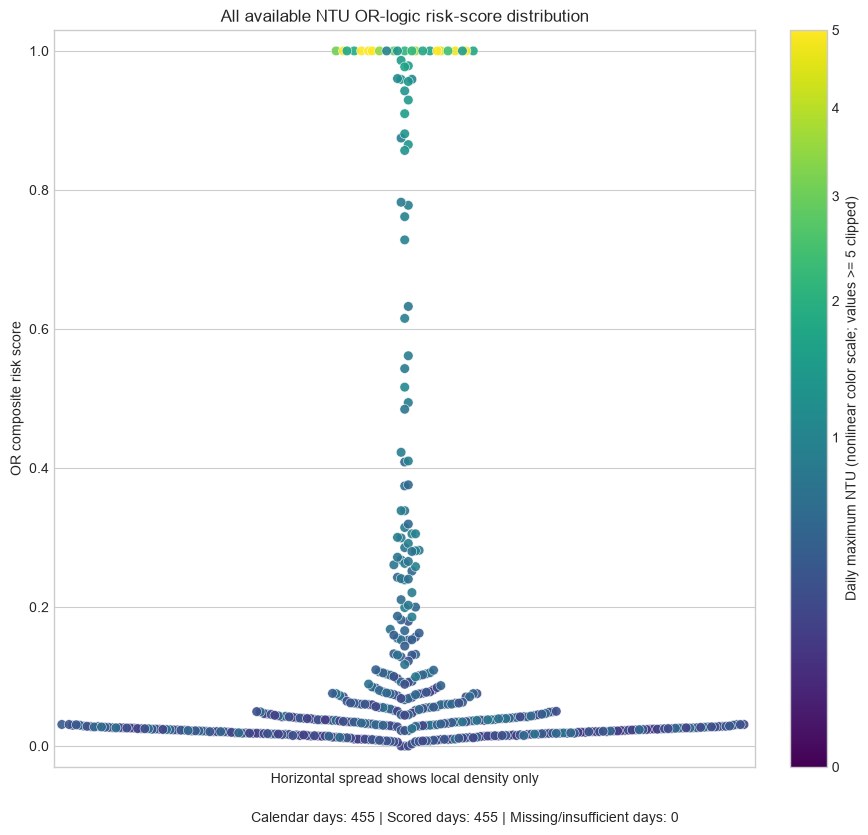

In [16]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.unicode_minus"] = False

all_plot = daily_scores.dropna(subset=["OR_risk_score", "max_NTU"]).copy()

def continuous_swarm_offsets(values, y_radius=0.022, x_radius=0.055):
    # Greedy beeswarm layout: preserve y and use x only to prevent overlaps.
    values = np.asarray(values, dtype=float)
    offsets = np.zeros(len(values), dtype=float)
    placed = []
    order = np.argsort(values)
    candidates = [0.0]
    for level in range(1, len(values) + 1):
        candidates.extend([level * x_radius, -level * x_radius])

    for index in order:
        y_value = values[index]
        nearby = [
            previous_index for previous_index in placed
            if abs(values[previous_index] - y_value) < y_radius
        ]
        for candidate in candidates:
            has_overlap = False
            for previous_index in nearby:
                dx = (candidate - offsets[previous_index]) / x_radius
                dy = (y_value - values[previous_index]) / y_radius
                if dx * dx + dy * dy < 1.0:
                    has_overlap = True
                    break
            if not has_overlap:
                offsets[index] = candidate
                break
        placed.append(index)
    return offsets

all_plot["swarm_x"] = continuous_swarm_offsets(
    all_plot["OR_risk_score"].to_numpy()
)

# Use a nonlinear scale so color changes gradually slow down at higher NTU.
color_min = 0.0
color_max = 5.0
norm = mpl.colors.PowerNorm(
    gamma=0.5, vmin=color_min, vmax=color_max, clip=True
)
cmap = mpl.colormaps["viridis"]

fig, ax = plt.subplots(figsize=(9.4, 8.4))
ax.scatter(
    all_plot["swarm_x"],
    all_plot["OR_risk_score"],
    c=all_plot["max_NTU"],
    cmap=cmap,
    norm=norm,
    s=48,
    linewidth=0.4,
    edgecolor="white",
    alpha=0.90,
)

ax.set(
    xlabel="Horizontal spread shows local density only",
    ylabel="OR composite risk score",
    title="All available NTU OR-logic risk-score distribution",
)
ax.set_ylim(-0.03, 1.03)
ax.set_xticks([])
max_offset = max(abs(all_plot["swarm_x"]).max(), 0.25)
ax.set_xlim(-max_offset - 0.12, max_offset + 0.12)
ax.grid(axis="x", visible=False)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.04)
cbar.set_label("Daily maximum NTU (nonlinear color scale; values >= 5 clipped)")
cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])

scored_days = int(daily_scores["OR_risk_score"].notna().sum())
unscored_days = int(daily_scores["OR_risk_score"].isna().sum())
fig.text(
    0.5, 0.015,
    f"Calendar days: {len(daily_scores)} | Scored days: {scored_days} | Missing/insufficient days: {unscored_days}",
    ha="center", fontsize=10
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 7. 指标说明与 Excel 导出

In [17]:
indicator_definitions = pd.DataFrame([
    {
        "indicator": "max_excess",
        "definition": "max(max(NTU - 1, 0))",
        "risk_cap": RISK_CAPS["max_excess"],
        "unit": "NTU",
    },
    {
        "indicator": "exceed_ratio",
        "definition": "count(NTU > 1) / valid point count",
        "risk_cap": RISK_CAPS["exceed_ratio"],
        "unit": "proportion",
    },
    {
        "indicator": "median_excess",
        "definition": "median(NTU - 1) among NTU > 1 points; 0 when no exceedance",
        "risk_cap": RISK_CAPS["median_excess"],
        "unit": "NTU",
    },
    {
        "indicator": "ntu_std",
        "definition": "daily population standard deviation of valid NTU, ddof=0",
        "risk_cap": RISK_CAPS["ntu_std"],
        "unit": "NTU",
    },
    {
        "indicator": "longest_rising_steps",
        "definition": "longest consecutive 2-hour rising comparisons with both NTU values > 0.7",
        "risk_cap": RISK_CAPS["longest_rising_steps"],
        "unit": "steps",
    },
    {
        "indicator": "OR_risk_score",
        "definition": "1 - product(1 - r_i), with r_i = clip(indicator / risk_cap, 0, 1)",
        "risk_cap": np.nan,
        "unit": "[0, 1]",
    },
])

method_parameters = pd.DataFrame({
    "parameter": [
        "standard_limit_NTU", "warning_level_NTU", "operation_day_start",
        "operation_day_end", "expected_interval_hours",
        "expected_points_per_day", "minimum_valid_points_to_score",
        "classification_thresholds"
    ],
    "value": [
        STANDARD_LIMIT, WARNING_LEVEL, "07:00", "next day 05:00", 2,
        EXPECTED_POINTS_PER_DAY, MIN_VALID_POINTS, "Not set in this notebook"
    ]
})

with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:
    source_audit.to_excel(writer, sheet_name="source_audit", index=False)
    p4_input_audit.to_excel(writer, sheet_name="p3_forecast_input_audit", index=False)
    february_forecast_long.to_excel(writer, sheet_name="p3_feb_forecast_long", index=False)
    q1_summary.to_excel(writer, sheet_name="Q1_summary", index=False)
    daily_scores.to_excel(writer, sheet_name="all_daily_scores", index=False)
    q1.to_excel(writer, sheet_name="2026Q1_calendar", index=False)
    march.to_excel(writer, sheet_name="March_daily_scores", index=False)
    indicator_definitions.to_excel(writer, sheet_name="indicator_definitions", index=False)
    method_parameters.to_excel(writer, sheet_name="method_parameters", index=False)


def format_workbook(path):
    workbook = load_workbook(path)
    header_fill = PatternFill("solid", fgColor="1F4E78")
    header_font = Font(color="FFFFFF", bold=True)
    alternate_fill = PatternFill("solid", fgColor="DCE6F1")

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions

        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for row_index in range(2, worksheet.max_row + 1):
            if row_index % 2 == 0:
                for cell in worksheet[row_index]:
                    cell.fill = alternate_fill

        for column_index, column_cells in enumerate(worksheet.columns, start=1):
            max_length = max(
                len(str(cell.value)) if cell.value is not None else 0
                for cell in column_cells[: min(len(column_cells), 250)]
            )
            worksheet.column_dimensions[get_column_letter(column_index)].width = min(max(max_length + 2, 11), 42)

        for row in worksheet.iter_rows(min_row=2):
            for cell in row:
                if isinstance(cell.value, pd.Timestamp):
                    cell.value = cell.value.to_pydatetime()
                if hasattr(cell.value, "year") and hasattr(cell.value, "month"):
                    cell.number_format = "yyyy-mm-dd"

    workbook.save(path)


format_workbook(EXCEL_PATH)
print("Excel 已保存：", EXCEL_PATH)
display(indicator_definitions)

Excel 已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\p4\outputs\problem4_OR_with_P3_feb_forecast.xlsx


,indicator,definition,risk_cap,unit
0,max_excess,"max(max(NTU - 1, 0))",4.0000,NTU
1,exceed_ratio,count(NTU > 1) / valid point count,0.5000,proportion
2,median_excess,median(NTU - 1) among NTU > 1 points; 0 when n...,0.5000,NTU
3,ntu_std,daily population standard deviation of valid N...,0.5000,NTU
4,longest_rising_steps,longest consecutive 2-hour rising comparisons ...,4.0000,steps
5,OR_risk_score,"1 - product(1 - r_i), with r_i = clip(indicato...",NaN,"[0, 1]"


## 8. 自动验证

In [18]:
# 1) 跨午夜运行日归属与完整日点数
sample_midnight = data[data["DATETIME"].dt.hour.isin([1, 3, 5])].head(20)
assert (
    sample_midnight["OP_DATE"]
    == (sample_midnight["DATETIME"] - pd.Timedelta(days=1)).dt.normalize()
).all()
assert (daily_scores.loc[daily_scores["is_complete_day"], "n_valid"] == 12).all()

# 2) 人工序列验证连续上升、0.7 阈值和缺口重置
test_group = pd.DataFrame({
    "DATETIME": pd.to_datetime([
        "2026-01-01 07:00", "2026-01-01 09:00", "2026-01-01 11:00",
        "2026-01-01 13:00", "2026-01-01 17:00", "2026-01-01 19:00",
    ]),
    TARGET_COL: [0.71, 0.75, 0.82, np.nan, 0.90, 0.95],
})
assert longest_rising_steps(test_group) == 2

# 3) 归一化指标和 OR 评分范围
scored = daily_scores[daily_scores["can_score"]]
assert scored[NORMALIZED_INDICATORS].ge(0).all().all()
assert scored[NORMALIZED_INDICATORS].le(1).all().all()
assert scored["OR_risk_score"].between(0, 1).all()

# 4) 未超标日的前三项超标指标必须为 0
non_exceed_days = scored[scored["max_NTU"] <= STANDARD_LIMIT]
assert (non_exceed_days[["max_excess", "exceed_ratio", "median_excess"]] == 0).all().all()

# 5) 评分门槛与覆盖率
assert daily_scores.loc[daily_scores["n_valid"] < MIN_VALID_POINTS, "OR_risk_score"].isna().all()
assert daily_scores.loc[daily_scores["n_valid"] >= MIN_VALID_POINTS, "OR_risk_score"].notna().all()
assert np.allclose(
    daily_scores["data_coverage"],
    daily_scores["n_valid"] / EXPECTED_POINTS_PER_DAY,
    equal_nan=True,
)

# 6) 2026Q1 日历完整且缺失日不是零风险
assert len(q1) == 90
assert q1["OP_DATE"].nunique() == 90
assert q1.loc[q1["can_score"] != True, "OR_risk_score"].isna().all()

# 7) Excel 输出存在；蜂群图仅内嵌在 notebook 中
assert EXCEL_PATH.exists()

print("全部自动验证通过。")
print(f"2026Q1：{q1['OR_risk_score'].notna().sum()} 个可评分日，{q1['OR_risk_score'].isna().sum()} 个缺失/不足日。")

全部自动验证通过。
2026Q1：90 个可评分日，0 个缺失/不足日。


## 9. 结果使用说明

本 notebook 只给出连续 OR 风险评分，不生成风险等级或等级占比。

后续可结合蜂群图中评分密度、每日最大 NTU 的颜色变化及赛题解释需求，人工选择三个分界点，
再将评分映射为安全、低风险、中风险和高风险。分级时可额外实施“全天未超标的日期最高只判低风险”
这一业务约束，而无需修改这里的原始连续评分。

## 10. 按蜂群图界线进行四级风险分类

根据人工绘制的三条红线，结合坐标轴标定，采用以下数值界线：

| OR 综合评分 | 初始风险类型 |
|---:|---|
| \(R < 0.05\) | 安全 |
| \(0.05 <= R < 0.20\) | 低风险 |
| \(0.20 <= R < 0.99\) | 中风险 |
| \(R >= 0.99\) | 高风险 |

在初始评分分类后施加出厂水浊度硬约束：

1. 当日最大 `NTU > 1` 时，最终等级不得低于**中风险**；
2. 当日最大 `NTU < 1` 时，最终等级不得高于**低风险**；
3. 当日最大 `NTU = 1` 时不额外调整；
4. 缺失或有效点不足的日期保持未分类。

该约束只在必要时改变等级，并保留约束前后的分类结果以便审计。

In [19]:
RISK_BOUNDARIES = {
    "safe_low": 0.10,
    "low_moderate": 0.40,
    "moderate_high": 0.99,
}
RISK_LEVELS = ["安全", "低风险", "中风险", "高风险"]
RISK_ORDER_MAP = {level: index for index, level in enumerate(RISK_LEVELS)}

boundary_table = pd.DataFrame([
    {
        "risk_level": "安全",
        "OR_score_interval": "R <= 0.10",
        "lower_bound": 0.00,
        "upper_bound": 0.10,
        "lower_inclusive": True,
        "upper_inclusive": True,
    },
    {
        "risk_level": "低风险",
        "OR_score_interval": "0.10 < R <= 0.40",
        "lower_bound": 0.10,
        "upper_bound": 0.40,
        "lower_inclusive": False,
        "upper_inclusive": True,
    },
    {
        "risk_level": "中风险",
        "OR_score_interval": "0.40 < R < 0.99",
        "lower_bound": 0.40,
        "upper_bound": 0.99,
        "lower_inclusive": False,
        "upper_inclusive": False,
    },
    {
        "risk_level": "高风险",
        "OR_score_interval": "R >= 0.99",
        "lower_bound": 0.99,
        "upper_bound": 1.00,
        "lower_inclusive": True,
        "upper_inclusive": True,
    },
])

display(boundary_table)

,risk_level,OR_score_interval,lower_bound,upper_bound,lower_inclusive,upper_inclusive
0,安全,R <= 0.10,0.0000,0.1000,True,True
1,低风险,0.10 < R <= 0.40,0.1000,0.4000,False,True
2,中风险,0.40 < R < 0.99,0.4000,0.9900,False,False
3,高风险,R >= 0.99,0.9900,1.0000,True,True


### 10.1 初始分类与 NTU 硬约束

In [20]:
def classify_by_score(score):
    if pd.isna(score):
        return pd.NA
    if score <= RISK_BOUNDARIES["safe_low"]:
        return "安全"
    if score <= RISK_BOUNDARIES["low_moderate"]:
        return "低风险"
    if score < RISK_BOUNDARIES["moderate_high"]:
        return "中风险"
    return "高风险"


def apply_ntu_constraint(row):
    initial = row["initial_risk"]
    max_ntu = row["max_NTU"]

    if pd.isna(initial) or pd.isna(max_ntu):
        return initial, "未分类或无最大 NTU", False

    # NTU > 1: at least moderate risk.
    if max_ntu > STANDARD_LIMIT and RISK_ORDER_MAP[initial] < RISK_ORDER_MAP["中风险"]:
        return "中风险", "max_NTU > 1，强制不低于中风险", True

    # NTU < 1: at most low risk.
    if max_ntu < STANDARD_LIMIT and RISK_ORDER_MAP[initial] > RISK_ORDER_MAP["低风险"]:
        return "低风险", "max_NTU < 1，强制不高于低风险", True

    return initial, "未触发约束", False


classified_daily = daily_scores.copy()
classified_daily["initial_risk"] = classified_daily["OR_risk_score"].map(
    classify_by_score
)

constraint_result = classified_daily.apply(
    apply_ntu_constraint, axis=1, result_type="expand"
)
classified_daily["final_risk"] = constraint_result[0]
classified_daily["constraint_reason"] = constraint_result[1]
classified_daily["changed_by_constraint"] = constraint_result[2].fillna(False).astype(bool)

classified_daily["classification_change"] = np.where(
    classified_daily["changed_by_constraint"],
    classified_daily["initial_risk"].astype(str)
    + " -> "
    + classified_daily["final_risk"].astype(str),
    "未改变",
)

display(
    classified_daily.loc[
        classified_daily["OR_risk_score"].notna(),
        [
            "OP_DATE", "OR_risk_score", "max_NTU", "initial_risk",
            "final_risk", "changed_by_constraint", "constraint_reason"
        ],
    ].head(20)
)

,OP_DATE,OR_risk_score,max_NTU,initial_risk,final_risk,changed_by_constraint,constraint_reason
0,2025-01-01,0.0099,0.1200,安全,安全,False,未触发约束
1,2025-01-02,0.0197,0.1300,安全,安全,False,未触发约束
2,2025-01-03,0.0144,0.1300,安全,安全,False,未触发约束
3,2025-01-04,0.0224,0.1500,安全,安全,False,未触发约束
4,2025-01-05,0.0141,0.1300,安全,安全,False,未触发约束
5,2025-01-06,0.0166,0.1300,安全,安全,False,未触发约束
6,2025-01-07,0.0223,0.1500,安全,安全,False,未触发约束
7,2025-01-08,0.0200,0.1400,安全,安全,False,未触发约束
8,2025-01-09,0.0399,0.2000,安全,安全,False,未触发约束
9,2025-01-10,0.0407,0.1900,安全,安全,False,未触发约束


### 10.2 全历史分类统计

In [21]:
scored_classified = classified_daily.dropna(
    subset=["OR_risk_score", "initial_risk", "final_risk"]
).copy()

initial_counts = (
    scored_classified["initial_risk"]
    .value_counts()
    .reindex(RISK_LEVELS, fill_value=0)
)
final_counts = (
    scored_classified["final_risk"]
    .value_counts()
    .reindex(RISK_LEVELS, fill_value=0)
)

classification_summary = pd.DataFrame({
    "risk_level": RISK_LEVELS,
    "initial_days": [int(initial_counts[level]) for level in RISK_LEVELS],
    "initial_share": [
        initial_counts[level] / len(scored_classified) for level in RISK_LEVELS
    ],
    "final_days": [int(final_counts[level]) for level in RISK_LEVELS],
    "final_share": [
        final_counts[level] / len(scored_classified) for level in RISK_LEVELS
    ],
})
classification_summary["day_change"] = (
    classification_summary["final_days"]
    - classification_summary["initial_days"]
)

constraint_summary = pd.DataFrame({
    "item": [
        "全历史日历日",
        "可评分并分类日",
        "缺失或有效点不足日",
        "因 NTU 硬约束改变分类的日期数",
        "改变分类占可分类日比例",
        "max_NTU > 1 导致上调的日期数",
        "max_NTU < 1 导致下调的日期数",
    ],
    "value": [
        len(classified_daily),
        len(scored_classified),
        classified_daily["OR_risk_score"].isna().sum(),
        scored_classified["changed_by_constraint"].sum(),
        scored_classified["changed_by_constraint"].mean(),
        (
            scored_classified["changed_by_constraint"]
            & scored_classified["max_NTU"].gt(STANDARD_LIMIT)
        ).sum(),
        (
            scored_classified["changed_by_constraint"]
            & scored_classified["max_NTU"].lt(STANDARD_LIMIT)
        ).sum(),
    ],
})

change_direction = (
    scored_classified.loc[scored_classified["changed_by_constraint"]]
    .groupby(
        ["initial_risk", "final_risk", "constraint_reason"],
        dropna=False,
    )
    .size()
    .rename("days")
    .reset_index()
    .sort_values("days", ascending=False)
)

display(classification_summary)
display(constraint_summary)
display(change_direction)

,risk_level,initial_days,initial_share,final_days,final_share,day_change
0,安全,341,0.7495,341,0.7495,0
1,低风险,63,0.1385,78,0.1714,15
2,中风险,28,0.0615,14,0.0308,-14
3,高风险,23,0.0505,22,0.0484,-1


,item,value
0,全历史日历日,455.0000
1,可评分并分类日,455.0000
2,缺失或有效点不足日,0.0000
3,因 NTU 硬约束改变分类的日期数,15.0000
4,改变分类占可分类日比例,0.0330
5,max_NTU > 1 导致上调的日期数,0.0000
6,max_NTU < 1 导致下调的日期数,15.0000


,initial_risk,final_risk,constraint_reason,days
0,中风险,低风险,max_NTU < 1，强制不高于低风险,14
1,高风险,低风险,max_NTU < 1，强制不高于低风险,1


### 10.3 因硬约束改变分类的具体日期

In [22]:
constraint_changed_days = (
    scored_classified.loc[
        scored_classified["changed_by_constraint"],
        [
            "OP_DATE", "OR_risk_score", "max_NTU", "mean_NTU",
            *RAW_INDICATORS, *NORMALIZED_INDICATORS,
            "initial_risk", "final_risk", "classification_change",
            "constraint_reason", "n_valid", "data_coverage",
        ],
    ]
    .sort_values(["OP_DATE"])
    .reset_index(drop=True)
)

display(constraint_changed_days)
print(
    f"共 {len(constraint_changed_days)} 个点因 NTU 硬约束改变分类。"
)

,OP_DATE,OR_risk_score,max_NTU,mean_NTU,max_excess,exceed_ratio,median_excess,ntu_std,longest_rising_steps,r_max_excess,r_exceed_ratio,r_median_excess,r_ntu_std,r_longest_rising_steps,initial_risk,final_risk,classification_change,constraint_reason,n_valid,data_coverage
0,2025-01-29,0.5615,0.8500,0.5300,0.0000,0.0000,0.0000,0.2076,1,0.0000,0.0000,0.0000,0.4153,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
1,2025-02-05,0.8746,0.9100,0.6325,0.0000,0.0000,0.0000,0.2493,3,0.0000,0.0000,0.0000,0.4985,0.7500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
2,2025-02-16,0.4086,0.5400,0.2767,0.0000,0.0000,0.0000,0.2043,0,0.0000,0.0000,0.0000,0.4086,0.0000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
3,2025-03-23,0.6152,0.8900,0.4508,0.0000,0.0000,0.0000,0.2435,1,0.0000,0.0000,0.0000,0.4870,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
4,2025-05-10,0.4941,0.8700,0.4358,0.0000,0.0000,0.0000,0.2471,0,0.0000,0.0000,0.0000,0.4941,0.0000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
5,2025-08-02,0.4845,0.7500,0.3633,0.0000,0.0000,0.0000,0.2423,0,0.0000,0.0000,0.0000,0.4845,0.0000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
6,2025-09-06,0.7282,0.9900,0.6092,0.0000,0.0000,0.0000,0.2282,2,0.0000,0.0000,0.0000,0.4563,0.5000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
7,2025-10-02,0.6324,0.7900,0.5542,0.0000,0.0000,0.0000,0.1324,2,0.0000,0.0000,0.0000,0.2649,0.5000,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
8,2025-10-27,0.4226,0.8800,0.7508,0.0000,0.0000,0.0000,0.1151,1,0.0000,0.0000,0.0000,0.2301,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000
9,2025-11-19,0.4101,0.9200,0.6142,0.0000,0.0000,0.0000,0.1067,1,0.0000,0.0000,0.0000,0.2135,0.2500,中风险,低风险,中风险 -> 低风险,max_NTU < 1，强制不高于低风险,12,1.0000


共 15 个点因 NTU 硬约束改变分类。


### 10.4 2026 年第一季度与 3 月统计

In [23]:
q1_calendar_full = pd.DataFrame({"OP_DATE": pd.date_range(Q1_START, Q1_END, freq="D")})
march_calendar_full = pd.DataFrame({"OP_DATE": pd.date_range(MARCH_START, MARCH_END, freq="D")})

q1_classified = q1_calendar_full.merge(classified_daily, on="OP_DATE", how="left")
march_classified = march_calendar_full.merge(classified_daily, on="OP_DATE", how="left")

def fill_unclassified_calendar_rows(frame):
    missing = frame["n_valid"].isna()
    frame.loc[missing, "n_expected"] = EXPECTED_POINTS_PER_DAY
    frame.loc[missing, "n_valid"] = 0
    frame.loc[missing, "data_coverage"] = 0.0
    frame.loc[missing, "is_complete_day"] = False
    frame.loc[missing, "can_score"] = False
    frame.loc[missing, "data_status"] = "无观测记录，不评分"
    frame.loc[missing, "constraint_reason"] = "无观测记录，不评分"
    frame.loc[missing, "classification_change"] = "未分类"
    frame.loc[missing, "changed_by_constraint"] = False

    frame["n_expected"] = frame["n_expected"].fillna(EXPECTED_POINTS_PER_DAY).astype(int)
    frame["n_valid"] = frame["n_valid"].fillna(0).astype(int)
    frame["data_coverage"] = frame["data_coverage"].fillna(0.0)
    frame["is_complete_day"] = frame["is_complete_day"].fillna(False).astype(bool)
    frame["can_score"] = frame["can_score"].fillna(False).astype(bool)
    frame["changed_by_constraint"] = frame["changed_by_constraint"].fillna(False).astype(bool)
    return frame

q1_classified = fill_unclassified_calendar_rows(q1_classified)
march_classified = fill_unclassified_calendar_rows(march_classified)

def summarize_period(frame, period_name):
    valid = frame.dropna(subset=["final_risk"])
    counts = valid["final_risk"].value_counts().reindex(RISK_LEVELS, fill_value=0)

    rows = []
    for level in RISK_LEVELS:
        rows.append({
            "period": period_name,
            "risk_level": level,
            "days": int(counts[level]),
            "calendar_days": len(frame),
            "classified_days": len(valid),
            "unclassified_days": len(frame) - len(valid),
            "share_among_calendar_days": counts[level] / len(frame) if len(frame) else np.nan,
            "share_among_classified_days": counts[level] / len(valid) if len(valid) else np.nan,
            "constraint_changed_days": int(valid["changed_by_constraint"].sum()) if len(valid) else 0,
        })

    rows.append({
        "period": period_name,
        "risk_level": "未分类/不评分",
        "days": int(len(frame) - len(valid)),
        "calendar_days": len(frame),
        "classified_days": len(valid),
        "unclassified_days": len(frame) - len(valid),
        "share_among_calendar_days": (len(frame) - len(valid)) / len(frame) if len(frame) else np.nan,
        "share_among_classified_days": np.nan,
        "constraint_changed_days": int(valid["changed_by_constraint"].sum()) if len(valid) else 0,
    })

    return pd.DataFrame(rows)

period_summary = pd.concat([
    summarize_period(q1_classified, "2026Q1"),
    summarize_period(march_classified, "2026-03"),
], ignore_index=True)

march_classification = march_classified[[
    "OP_DATE", "n_valid", "data_status", "mean_NTU", "max_NTU",
    "OR_risk_score", "initial_risk", "final_risk",
    "changed_by_constraint", "constraint_reason",
]].copy()

display(period_summary)
display(march_classification)

assert len(q1_classified) == 90
assert len(march_classified) == 31
assert period_summary.query("period == '2026Q1'")["days"].sum() == 90
assert period_summary.query("period == '2026-03'")["days"].sum() == 31

,period,risk_level,days,calendar_days,classified_days,unclassified_days,share_among_calendar_days,share_among_classified_days,constraint_changed_days
0,2026Q1,安全,76,90,90,0,0.8444,0.8444,0
1,2026Q1,低风险,10,90,90,0,0.1111,0.1111,0
2,2026Q1,中风险,1,90,90,0,0.0111,0.0111,0
3,2026Q1,高风险,3,90,90,0,0.0333,0.0333,0
4,2026Q1,未分类/不评分,0,90,90,0,0.0000,NaN,0
5,2026-03,安全,25,31,31,0,0.8065,0.8065,0
6,2026-03,低风险,4,31,31,0,0.1290,0.1290,0
7,2026-03,中风险,1,31,31,0,0.0323,0.0323,0
8,2026-03,高风险,1,31,31,0,0.0323,0.0323,0
9,2026-03,未分类/不评分,0,31,31,0,0.0000,NaN,0


,OP_DATE,n_valid,data_status,mean_NTU,max_NTU,OR_risk_score,initial_risk,final_risk,changed_by_constraint,constraint_reason
0,2026-03-01,12,完整可评分,0.4525,0.4800,0.0318,安全,安全,False,未触发约束
1,2026-03-02,12,完整可评分,0.4733,0.4900,0.0298,安全,安全,False,未触发约束
2,2026-03-03,12,完整可评分,0.4933,0.5100,0.0275,安全,安全,False,未触发约束
3,2026-03-04,12,完整可评分,0.5017,0.5200,0.0325,安全,安全,False,未触发约束
4,2026-03-05,12,完整可评分,0.5308,0.5600,0.0331,安全,安全,False,未触发约束
5,2026-03-06,12,完整可评分,0.5400,0.5600,0.0183,安全,安全,False,未触发约束
6,2026-03-07,12,完整可评分,0.5250,0.5400,0.0224,安全,安全,False,未触发约束
7,2026-03-08,12,完整可评分,0.5367,0.5600,0.0275,安全,安全,False,未触发约束
8,2026-03-09,12,完整可评分,0.5442,0.5600,0.0191,安全,安全,False,未触发约束
9,2026-03-10,12,完整可评分,0.5392,0.5500,0.0152,安全,安全,False,未触发约束


### 10.5 将分类结果追加到原 Excel 工作簿

In [24]:
with pd.ExcelWriter(
    EXCEL_PATH, engine="openpyxl", mode="a", if_sheet_exists="replace"
) as writer:
    boundary_table.to_excel(
        writer, sheet_name="risk_boundaries", index=False
    )
    classified_daily.to_excel(
        writer, sheet_name="all_risk_classification", index=False
    )
    classification_summary.to_excel(
        writer, sheet_name="classification_summary", index=False
    )
    constraint_summary.to_excel(
        writer, sheet_name="constraint_summary", index=False
    )
    constraint_changed_days.to_excel(
        writer, sheet_name="constraint_changed_days", index=False
    )
    period_summary.to_excel(
        writer, sheet_name="period_risk_summary", index=False
    )
    march_classification.to_excel(
        writer, sheet_name="March_classification", index=False
    )

format_workbook(EXCEL_PATH)

assert classified_daily.loc[
    classified_daily["max_NTU"].gt(STANDARD_LIMIT)
    & classified_daily["final_risk"].notna(),
    "final_risk",
].map(RISK_ORDER_MAP).ge(RISK_ORDER_MAP["中风险"]).all()

assert classified_daily.loc[
    classified_daily["max_NTU"].lt(STANDARD_LIMIT)
    & classified_daily["final_risk"].notna(),
    "final_risk",
].map(RISK_ORDER_MAP).le(RISK_ORDER_MAP["低风险"]).all()

print("风险分类与硬约束验证通过。")
print("分类结果已追加至：", EXCEL_PATH)

风险分类与硬约束验证通过。
分类结果已追加至： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\p4\outputs\problem4_OR_with_P3_feb_forecast.xlsx


## 使用说明

该 notebook 的输出文件为：

```text
codes/p4/outputs/problem4_OR_with_P3_feb_forecast.xlsx
```

核心结果表：

- `p3_feb_forecast_long`：P3 模型预测出的 2 月 NTU 序列；
- `all_daily_scores`：P4 OR-risk 每日评分；
- `period_risk_summary`：2026Q1 与 3 月的风险等级统计；
- `March_classification`：3 月每日风险等级；
- `all_risk_classification`：完整分类结果。

论文描述建议：

> 本文首先采用第三题构建的 TW-Qin Formula-GRU 模型对 2026 年 2 月出厂水 NTU 进行递推预测，并将预测得到的 2 月 NTU 序列与 1 月和 3 月的观测 NTU 共同组成第一季度风险评价输入。随后保持第四题 OR-risk 评分体系不变，计算每日风险指标、综合风险分数和四级风险等级，从而形成“水质预测—风险评价”的连续决策链条。